In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [104]:
houses = pd.read_csv('houses.csv', sep=None, engine='python');
houses.name = "Houses"

In [105]:
print(f"Number of records (rows): {houses.shape[0]}")
print(f"Number of attributes (columns): {houses.shape[1]}")

Number of records (rows): 20640
Number of attributes (columns): 9


Attributes:
median_house_value – median value of houses in the area.
median_income – median income of households in the area.
housing_median_age – median age of houses in the area.
total_rooms – total number of rooms in all houses within the area.
total_bedrooms – total number of bedrooms in all houses within the area.
population – total number of people living in the area.
households – total number of households.
latitude – north–south geographical coordinate of the area.
longitude – east–west geographical coordinate of the area.

In [106]:
print(f"Attributs: {houses.columns.tolist()}")

Attributs: ['median_house_value', 'median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'latitude', 'longitude']


Data example:

In [107]:
houses.head(5)

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,452600.0,8.3,41.0,880.0,129.0,322.0,126.0,37.9,-122.2
1,358500.0,8.3,21.0,7099.0,1106.0,2401.0,1138.0,37.9,-122.2
2,352100.0,7.3,52.0,1467.0,190.0,496.0,177.0,37.9,-122.2
3,341300.0,5.6,52.0,1274.0,235.0,558.0,219.0,37.9,-122.2
4,342200.0,3.8,52.0,1627.0,280.0,565.0,259.0,37.9,-122.2


Number of duplicated records:

In [108]:
houses.duplicated().sum()

np.int64(0)

Number of missing values:

In [109]:
houses.isna().sum()

median_house_value    0
median_income         0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
latitude              0
longitude             0
dtype: int64

Cleaning outliers:

In [110]:
houses_cleaned = houses.copy()

for atr in houses_cleaned.columns:
    Q1 = houses_cleaned[atr].quantile(0.25)
    Q3 = houses_cleaned[atr].quantile(0.75)
    IQR = Q3 - Q1
    houses_cleaned = houses_cleaned[(houses_cleaned[atr] >= Q1 - 1.5 * IQR) & (houses_cleaned[atr] <= Q3 + 1.5 * IQR)]

print(f"Cleaned {houses.shape[0] - houses_cleaned.shape[0]} rows.")

Cleaned 3717 rows.


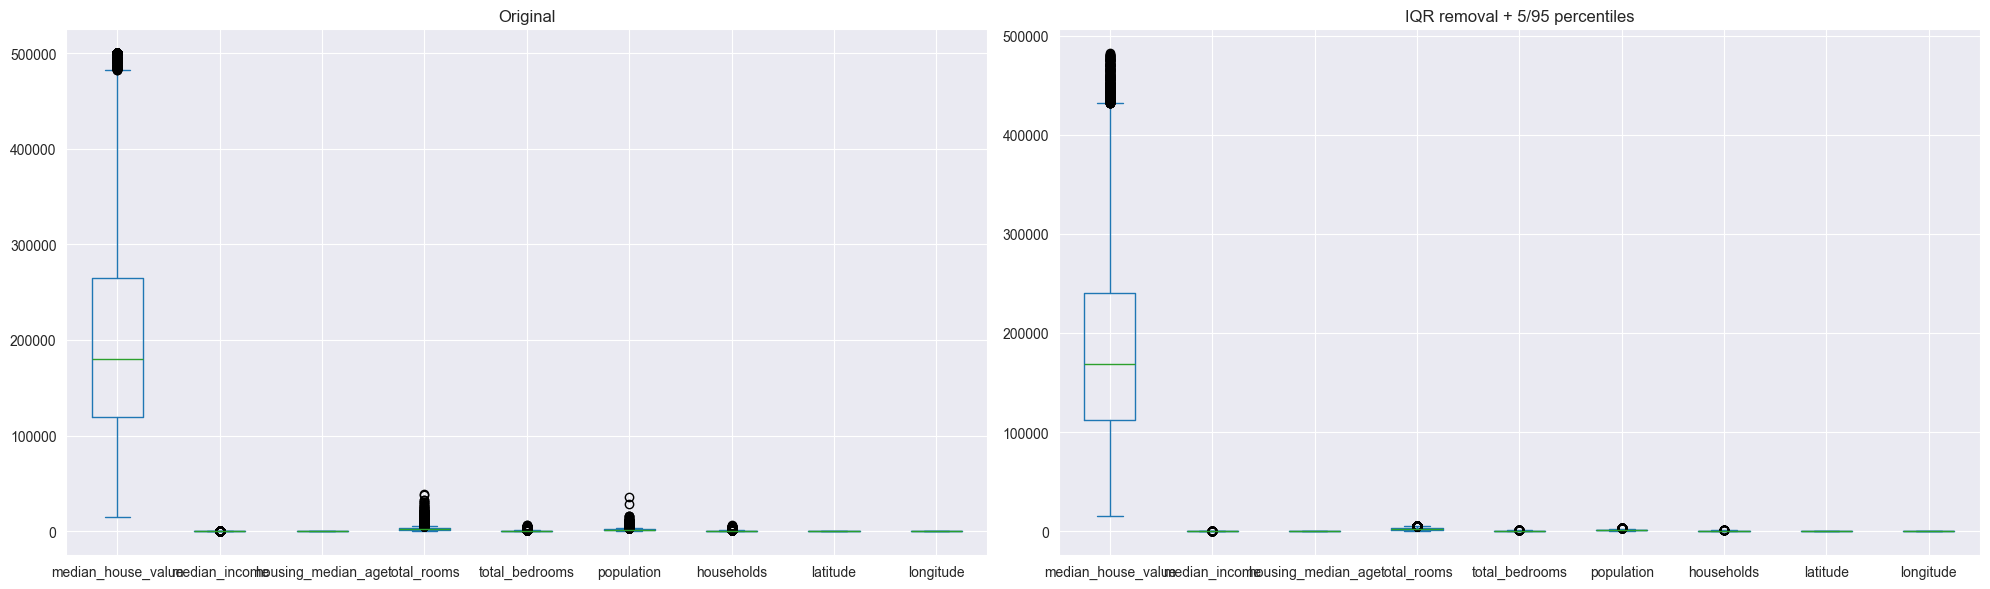

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
houses.plot.box(ax=axes[0], title="Original")
houses_cleaned.plot.box(ax=axes[1], title="IQR removal + 5/95 percentiles")
plt.tight_layout()
plt.show()

Mean, median, min, max, std  values of attributes after cleaning:

In [112]:
pd.options.display.float_format = "{:.1f}".format
houses_cleaned.describe()

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
count,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0
mean,185595.5,3.6,29.7,2075.4,428.7,1153.6,401.1,35.7,-119.6
std,93016.0,1.4,12.2,1026.1,202.1,553.7,187.4,2.2,2.0
min,14999.0,0.5,1.0,2.0,2.0,3.0,2.0,32.5,-124.3
25%,112500.0,2.5,20.0,1348.0,282.0,755.0,268.0,33.9,-121.8
50%,168800.0,3.4,30.0,1934.0,403.0,1088.0,380.0,34.4,-118.7
75%,240200.0,4.5,38.0,2692.0,557.0,1509.0,522.0,37.8,-118.0
max,482200.0,7.6,52.0,5600.0,1056.0,2762.0,916.0,42.0,-114.5


Attributes distribution: The difference interval for all attributes look valid.

array([[<Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>]], dtype=object)

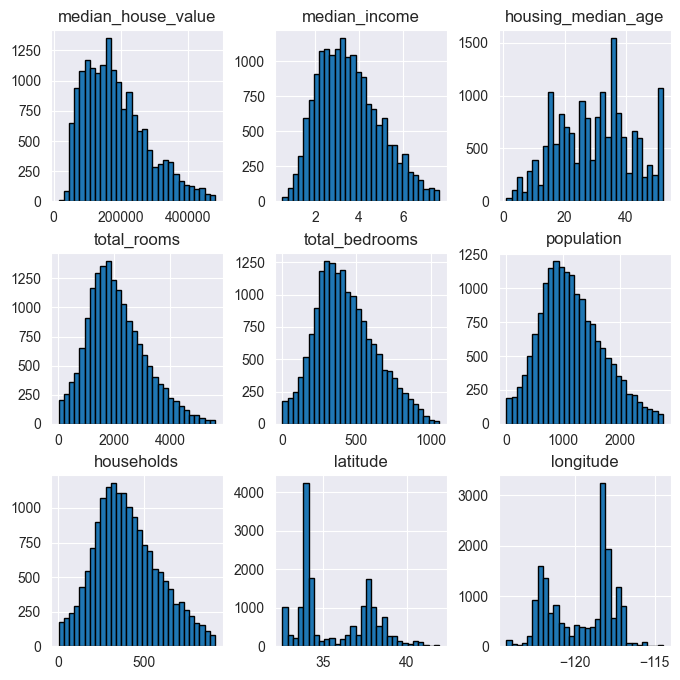

In [113]:
houses_cleaned.hist(figsize=(8, 8), bins=30, edgecolor='black')

None of the features have a strictly normal distribution. 'median_house_value', 'median_income', 'total_rooms', 'total_bedrooms', 'population', and 'households' have right-skewed distributions (skew > 0). 'housing_median_age' has a distribution similar to uniform. 'latitude' and 'longitude' are multi-peaked features, truncated by geography, clearly not normal.

In [114]:
houses_cleaned.skew()

median_house_value    0.8
median_income         0.5
housing_median_age   -0.0
total_rooms           0.6
total_bedrooms        0.5
population            0.5
households            0.4
latitude              0.4
longitude            -0.3
dtype: float64

Preliminary correlation analysis:
The main correlation that can be worked with is the correlation between attributes 'median_house_value' and 'median_income'. The remaining strong correlations are of no use because it is quite logical why they are so interrelated. If the value of 'total_bedrooms' increases, it is logical that the value of 'total_rooms' will also increase. The values of 'population' and 'households' will also increase because the more rooms there are, the more people can live in them, and more households will need to be built for these rooms.

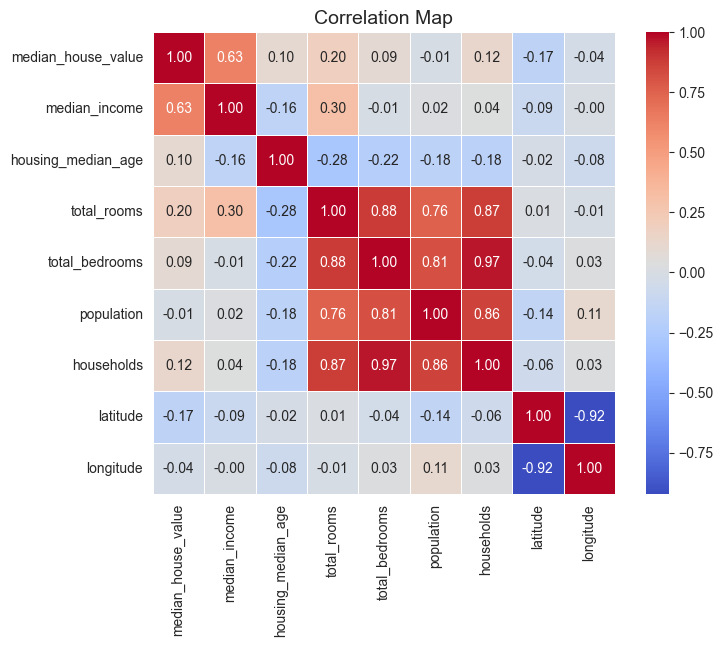

In [115]:
# Computing the correlation matrix
corr = houses_cleaned.corr(numeric_only=True)

# Plotting the map
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Map", fontsize=14)
plt.show()

Graph of the relationship between 'median_house_value' and 'median_income':

<Axes: xlabel='median_house_value', ylabel='median_income'>

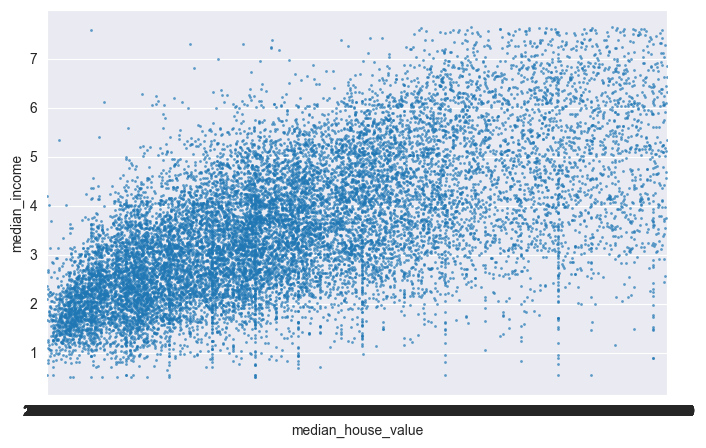

In [116]:
plt.figure(figsize=(8,5))
sns.stripplot(data=houses_cleaned, x="median_house_value", y="median_income", jitter=True, size=2, alpha=0.7)

In [117]:
houses_cleaned.columns

Index(['median_house_value', 'median_income', 'housing_median_age',
       'total_rooms', 'total_bedrooms', 'population', 'households', 'latitude',
       'longitude'],
      dtype='object')

Splitting dataset into features and target variable:

In [118]:
X = houses_cleaned.drop(columns='median_house_value')
y = houses_cleaned['median_house_value']

Data normalization: for ‘median_house_value’, ‘median_income’, ‘total_rooms’, ‘total_bedrooms’, ‘population’, ‘households’, we use logarithmic transformation because all values have right-skewed asymmetry, with a long tail to the right and a distribution that is not normal but closer to log-normal. Then, for all attributes, we perform robust scaling because of different scales and non-normal distribution.
We leave ‘latitude’ and ‘longitude’ untouched because they are geographical features and if we transform them, they will lose their informativeness.

In [119]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

X_scaler = Pipeline([
    ('log_transform', ColumnTransformer([('log', FunctionTransformer(np.log1p), [0, 1, 2, 3, 4, 5])], remainder='passthrough')),
    ('robust_scaling', ColumnTransformer([('robust', RobustScaler(), [0, 1, 2, 3, 4, 5])], remainder='passthrough'))
])

y_scaler = RobustScaler()


transformed_X = X_scaler.fit_transform(X)
transformed_y = y_scaler.fit_transform(y.values.reshape(-1, 1))

X_norm = pd.DataFrame(transformed_X, columns=X.columns)
y_norm = pd.DataFrame(transformed_y, columns=['median_house_value'])

X_norm.describe()

,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
count,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0,16923.0
mean,-0.0,-0.2,-0.1,-0.1,-0.1,-0.1,35.7,-119.6
std,0.7,0.8,0.9,0.9,0.9,0.9,2.2,2.0
min,-2.4,-4.4,-9.4,-7.2,-8.1,-7.3,32.5,-124.3
25%,-0.5,-0.6,-0.5,-0.5,-0.5,-0.5,33.9,-121.8
50%,0.0,0.0,0.0,0.0,0.0,0.0,34.4,-118.7
75%,0.5,0.4,0.5,0.5,0.5,0.5,37.8,-118.0
max,1.5,0.9,1.5,1.4,1.3,1.3,42.0,-114.5


How normalized data looks on histograms:

array([[<Axes: title={'center': 'median_house_value'}>]], dtype=object)

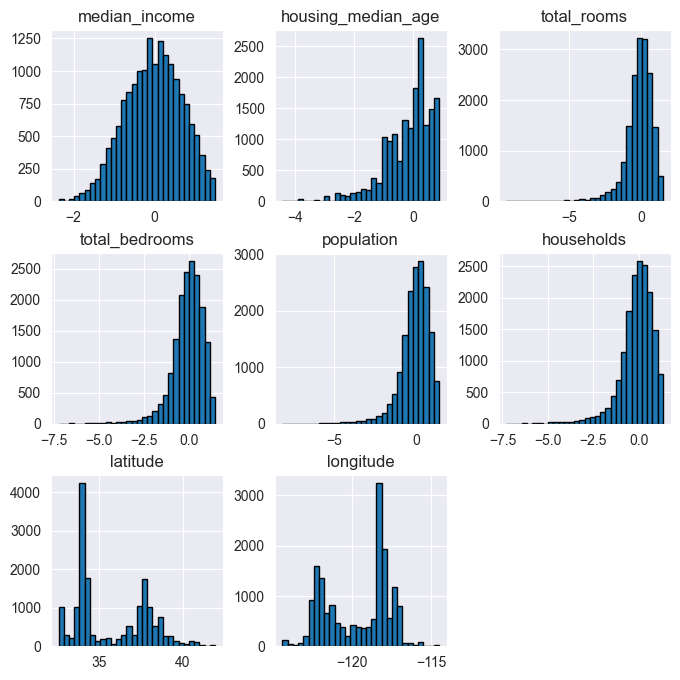

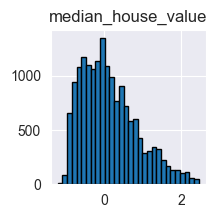

In [120]:
X_norm.hist(figsize=(8, 8), bins=30, edgecolor='black')
y_norm.hist(figsize=(2, 2), bins=30, edgecolor='black')

Splitting dataset into 2 parts: training(85%), and test(15%):

In [121]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.15, random_state=4)

Multi-layer Perceptron Regressor model configuration:

In [135]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

C:\Users\Dmytro\Pictures\MachineLearningCourse\.venv\python.exe\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [138]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=2,
    batch_size=32,
    verbose=1
)

Epoch 1/2
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step - loss: 0.0829 - mae: 0.2253 - val_loss: 0.0738 - val_mae: 0.2165
Epoch 2/2
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - loss: 0.0664 - mae: 0.1980 - val_loss: 0.0584 - val_mae: 0.1906


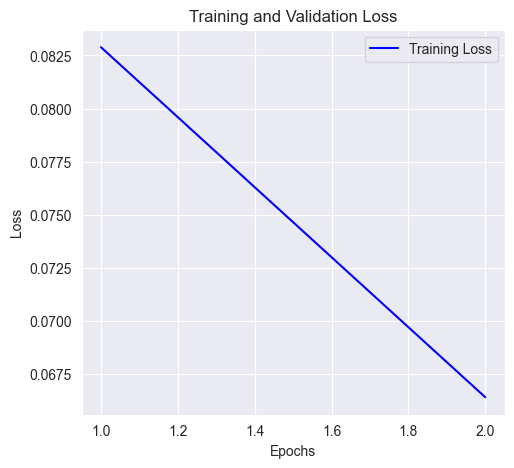

In [139]:
# Достаем историю обучения
loss = history.history['loss']
val_loss = history.history.get('val_loss')
mae = history.history.get('mae')
val_mae = history.history.get('val_mae')

epochs = range(1, len(loss) + 1)

# График функции потерь
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [140]:

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Предсказания модели (они в нормализованном масштабе)
y_pred_scaled = model.predict(X_test)

# Обратное преобразование
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test.values.reshape(-1, 1))

# Вычисляем метрики
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"Test Loss (MSE): {mse:.4f}, MAE: {mae:.4f}")

y_test.head()

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step
Test Loss (MSE): 955912571.6802, MAE: 24017.6882


,median_house_value
1404,0.3
3459,0.6
4971,0.6
6800,1.1
6548,-0.1


In [126]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,501 (9.77 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,668 (6.52 KB)